In [1]:
# ============================================================
# HYPOTHESIS: Students who take longer to complete the quiz
# tend to score higher
# ============================================================

# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ============================================================
# HYPOTHESIS: Students who take longer tend to score higher
# Raw data used as-is — no filtering, no assumptions
# ============================================================

# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.25,
    'grid.linestyle'     : '--',
    'figure.dpi'         : 130,
})

# ── Parse time string → seconds (handles hours/mins/secs) ──────
def parse_time_to_seconds(time_str):
    if pd.isna(time_str) or str(time_str).strip() in ['-', '']:
        return np.nan
    s = str(time_str).strip()
    total = 0
    h  = re.search(r'(\d+)\s*hour', s)
    m  = re.search(r'(\d+)\s*min',  s)
    sc = re.search(r'(\d+)\s*sec',  s)
    if h:  total += int(h.group(1))  * 3600
    if m:  total += int(m.group(1))  * 60
    if sc: total += int(sc.group(1))
    return total if total > 0 else np.nan

def load_quiz(filepath, quiz_name):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df = df[df['State'] == 'Finished'].copy()
    df['Time_Seconds'] = df['Time taken'].apply(parse_time_to_seconds)
    df['Time_Minutes'] = df['Time_Seconds'] / 60
    df['Grade']        = pd.to_numeric(df['Grade/10.00'], errors='coerce')
    df = df.dropna(subset=['Time_Seconds', 'Grade'])
    df['Quiz'] = quiz_name
    # Keep ALL attempts — no deduplication, use raw data
    return df[['Student Code', 'Time_Minutes', 'Grade', 'Quiz']]

# ── Update paths to match your Drive ──────────────────────────
quiz1 = load_quiz('/content/drive/MyDrive/quiz1_marks.csv', 'Quiz 1')
quiz2 = load_quiz('/content/drive/MyDrive/quiz2_marks.csv', 'Quiz 2')
quiz3 = load_quiz('/content/drive/MyDrive/quiz3_marks.csv', 'Quiz 3')
df = pd.concat([quiz1, quiz2, quiz3], ignore_index=True)

print(f"Loaded: Quiz1={len(quiz1)}, Quiz2={len(quiz2)}, Quiz3={len(quiz3)}, Total={len(df)}")
print(df[['Time_Minutes','Grade']].describe().round(2))

COLORS = {'Quiz 1': '#4C72B0', 'Quiz 2': '#C44E52', 'Quiz 3': '#55A868'}

Loaded: Quiz1=13888, Quiz2=10403, Quiz3=8055, Total=32346
       Time_Minutes     Grade
count      32346.00  32346.00
mean          29.85      4.72
std          138.73      2.78
min            0.18      0.00
25%            2.77      2.00
50%            6.00      4.00
75%           12.10      6.00
max         1439.00     10.00


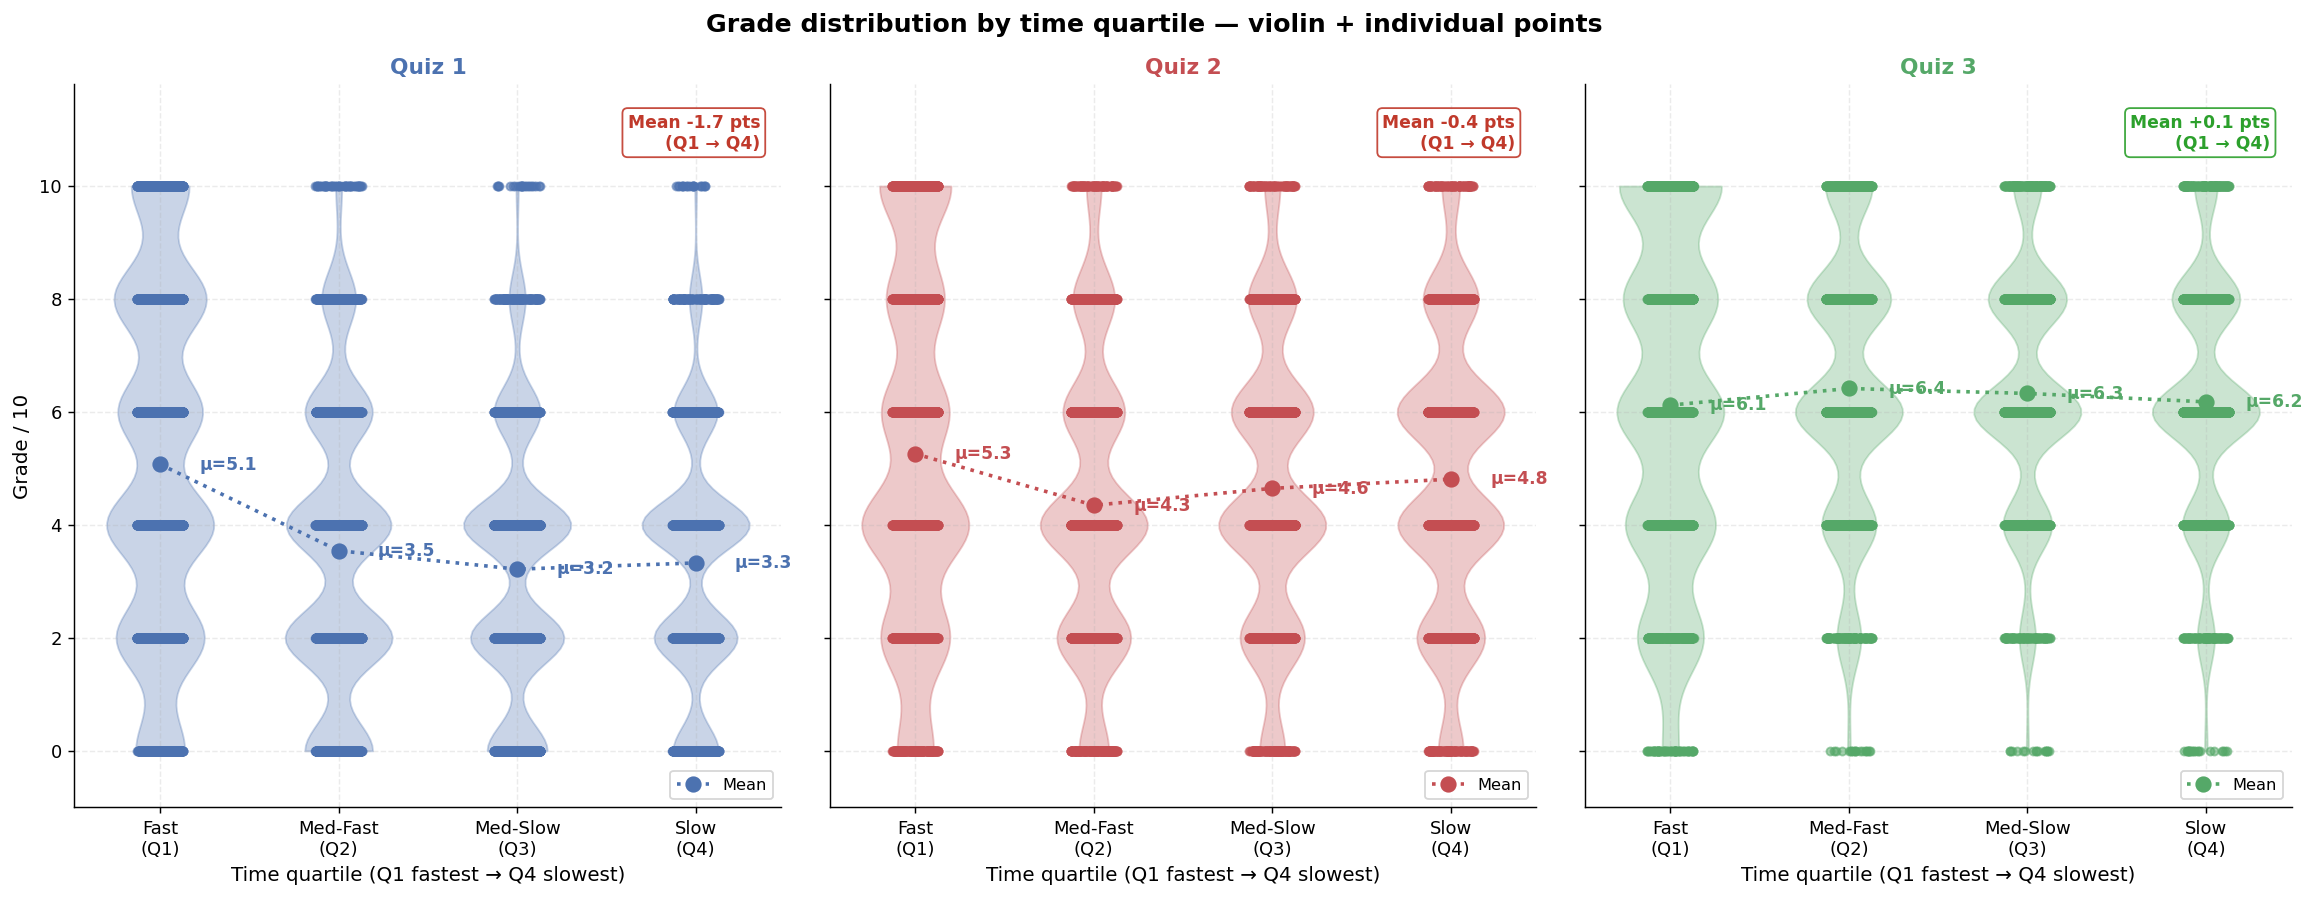

In [3]:
# ════════════════════════════════════════════════════════════════
# VIZ 3 — VIOLIN + STRIP PLOT BY TIME QUARTILE
#
#   Mark    : area (violin body), point (strip)
#   Channels: y = grade (quant), x = time quartile (ordinal),
#             violin width = density of grades at that level,
#             colour = quiz identity, median line = central tendency
#
#   Why this: Box plots show only 5 summary numbers and hide the
#   distribution SHAPE. Violins reveal that the grade distribution
#   is likely bimodal (students score either very low or very high).
#   The strip overlay shows every real data point so nothing is hidden.
#   If the hypothesis holds, the fat part of the violin should be
#   higher for Q4 (slowest) than Q1 (fastest).
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle(
    'Grade distribution by time quartile — violin + individual points  ',
    fontsize=14, fontweight='bold'
)

qlabels = ['Fast\n(Q1)', 'Med-Fast\n(Q2)', 'Med-Slow\n(Q3)', 'Slow\n(Q4)']

for ax, (qname, grp) in zip(axes, df.groupby('Quiz')):
    color = COLORS[qname]
    grp2  = grp.copy()
    grp2['Quartile'] = pd.qcut(grp2['Time_Minutes'], q=4,
                                labels=['Q1','Q2','Q3','Q4'])
    groups_data = [grp2[grp2['Quartile'] == q]['Grade'].dropna().values
                   for q in ['Q1','Q2','Q3','Q4']]

    # Only draw violin if enough data
    valid = [i for i, g in enumerate(groups_data) if len(g) >= 4]
    if valid:
        vp = ax.violinplot([groups_data[i] for i in valid],
                           positions=[i+1 for i in valid],
                           showmedians=True, showextrema=False, widths=0.6)
        for pc in vp['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.30); pc.set_edgecolor(color)
        vp['cmedians'].set_color(color); vp['cmedians'].set_linewidth(2.5)

    # Strip (jittered individual points)
    np.random.seed(1)
    for i, q in enumerate(['Q1','Q2','Q3','Q4'], start=1):
        sub = grp2[grp2['Quartile'] == q]['Grade'].values
        jit = np.random.uniform(-0.13, 0.13, len(sub))
        ax.scatter(np.full(len(sub), i) + jit, sub,
                   color=color, s=20, alpha=0.55, zorder=3)

    # Mean markers + connecting line
    means = [np.mean(d) if len(d) else np.nan for d in groups_data]
    ax.plot([1,2,3,4], means, color=color, marker='o', ms=8,
            lw=2, ls=':', zorder=4, label='Mean')
    for i, mv in enumerate(means, start=1):
        if not np.isnan(mv):
            ax.text(i + 0.22, mv, f'μ={mv:.1f}',
                    fontsize=9.5, color=color, fontweight='bold', va='center')

    # Delta annotation (fast → slow mean change)
    if not np.isnan(means[0]) and not np.isnan(means[3]):
        delta = means[3] - means[0]
        dstr  = f'Mean {"+" if delta>=0 else ""}{delta:.1f} pts\n(Q1 → Q4)'
        dcol  = '#2ca02c' if delta > 0 else '#c0392b'
        ax.text(0.97, 0.96, dstr, transform=ax.transAxes,
                fontsize=9.5, fontweight='bold', color=dcol,
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec=dcol, alpha=0.9))

    ax.set_xticks([1,2,3,4]); ax.set_xticklabels(qlabels, fontsize=10)
    ax.set_title(qname, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Time quartile (Q1 fastest → Q4 slowest)', fontsize=11)
    if ax is axes[0]: ax.set_ylabel('Grade / 10', fontsize=11)
    ax.set_ylim(-1, 11.8)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('viz3_violin_strip.png', dpi=150, bbox_inches='tight')
plt.show()